# Coffee & Bakery Point-of-Sale (POS) Analytics

## Business Context
Proyek ini menganalisis data transaksi kasir (*Point-of-Sale*) gerai *bakery and coffee shop*. Tujuannya adalah mengidentifikasi menu dengan kontribusi penjualan terbesar, menganalisis pola jam sibuk operasional untuk efisiensi jadwal staf, mengaudit menu yang kurang laku (*slow-moving*), serta memetakan produk kombo melalui *Market Basket Analysis*.

### Stack Teknologi:
* **Database & Query Engine:** SQLite, Advanced SQL (CTEs, Window Functions, Self-Joins, Conditional Aggregations)
* **Data Manipulation:** Python, Pandas, KaggleHub
* **Data Visualization:** Matplotlib, Seaborn

In [97]:
import sqlite3
import pandas as pd
import glob
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns

path = kagglehub.dataset_download("akashdeepkuila/bakery")
csv_files = glob.glob(f"{path}/*.csv")
df_raw = pd.read_csv(csv_files[0])

df_raw.columns = [col.strip().lower().replace(' ', '_') for col in df_raw.columns]
if 'items' in df_raw.columns:
    df_raw.rename(columns={'items': 'item_name', 'transaction': 'transaction_id', 'datetime': 'date_time'}, inplace=True)
elif 'item' in df_raw.columns:
    df_raw.rename(columns={'item': 'item_name', 'transaction': 'transaction_id'}, inplace=True)

df_raw['date_time'] = pd.to_datetime(df_raw['date_time'], format='mixed').dt.strftime('%Y-%m-%d %H:%M:%S')

conn = sqlite3.connect('fnb_retail_dw.db')
df_raw.to_sql('fact_pos_transactions', conn, if_exists='replace', index=False)

pd.read_sql("SELECT * FROM fact_pos_transactions LIMIT 5;", conn)

Using Colab cache for faster access to the 'bakery' dataset.


,transaction_id,item_name,date_time,period_day,weekday_weekend
0,1,Bread,2016-10-30 09:58:00,morning,weekend
1,2,Scandinavian,2016-10-30 10:05:00,morning,weekend
2,2,Scandinavian,2016-10-30 10:05:00,morning,weekend
3,3,Hot chocolate,2016-10-30 10:07:00,morning,weekend
4,3,Jam,2016-10-30 10:07:00,morning,weekend


## 1. Analisis Konsentrasi Penjualan (Pareto & Top Sellers)
Menghitung 10 menu terlaris beserta persentase kontribusinya terhadap seluruh volume penjualan menggunakan *Window Function* `SUM() OVER()`.

In [98]:
q_top10 = """
SELECT
    item_name,
    COUNT(*) AS total_units_sold,
    ROUND(CAST(COUNT(*) AS FLOAT) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS sales_share_pct
FROM fact_pos_transactions
GROUP BY item_name
ORDER BY total_units_sold DESC
LIMIT 10;
"""

df_top10 = pd.read_sql(q_top10, conn)
df_top10

,item_name,total_units_sold,sales_share_pct
0,Coffee,5471,26.68
1,Bread,3325,16.21
2,Tea,1435,7.00
3,Cake,1025,5.00
4,Pastry,856,4.17
5,Sandwich,771,3.76
6,Medialuna,616,3.00
7,Hot chocolate,590,2.88
8,Cookies,540,2.63
9,Brownie,379,1.85


## 2. Audit Menu Kurang Laku (Slow-Moving Items)
Menyaring daftar produk dengan total transaksi kurang dari 20 unit selama periode operasional menggunakan klausa `HAVING`. Menu-menu ini dievaluasi untuk efisiensi inventaris bahan baku.

In [99]:
q_slow = """
SELECT
    item_name,
    COUNT(*) AS total_transactions
FROM fact_pos_transactions
GROUP BY item_name
HAVING COUNT(*) < 20
ORDER BY total_transactions ASC;
"""

df_slow = pd.read_sql(q_slow, conn)
df_slow.head(10)

,item_name,total_transactions
0,Adjustment,1
1,Bacon,1
2,Chicken sand,1
3,Gift voucher,1
4,Olum & polenta,1
5,Polenta,1
6,Raw bars,1
7,The BART,1
8,Bowl Nic Pitt,2
9,Chimichurri Oil,2


## 3. Utilisasi Waktu Operasional (Hourly Demand & Basket Size)
Mengekstrak jam transaksi menggunakan `STRFTIME` untuk mengidentifikasi jam sibuk (*peak hours*) dan memantau rata-rata jumlah item per transaksi (*basket size*).

In [100]:
q_hourly = """
SELECT
    STRFTIME('%H', date_time) AS order_hour,
    COUNT(DISTINCT transaction_id) AS unique_orders,
    COUNT(*) AS total_items_sold,
    ROUND(COUNT(*) * 1.0 / COUNT(DISTINCT transaction_id), 2) AS items_per_order
FROM fact_pos_transactions
GROUP BY order_hour
ORDER BY unique_orders DESC;
"""

df_hourly = pd.read_sql(q_hourly, conn)
df_hourly

,order_hour,unique_orders,total_items_sold,items_per_order
0,11,1439,3102,2.16
1,12,1325,2854,2.15
2,10,1266,2666,2.11
3,13,1143,2617,2.29
4,14,1120,2640,2.36
5,09,1006,1966,1.95
6,15,920,2115,2.30
7,16,581,1343,2.31
8,08,375,645,1.72
9,17,160,368,2.30


## 4. Market Basket Analysis (Coffee Product Association)
Mengidentifikasi produk makanan dan minuman pendamping yang paling sering dibeli bersamaan dengan produk utama (Coffee) dalam satu struk transaksi menggunakan teknik `SELF-JOIN`.

In [101]:
q_pairing = """
SELECT
    t2.item_name AS paired_item,
    COUNT(DISTINCT t1.transaction_id) AS transaction_co_occurrence
FROM fact_pos_transactions t1
JOIN fact_pos_transactions t2
    ON t1.transaction_id = t2.transaction_id
WHERE t1.item_name = 'Coffee'
  AND t2.item_name != 'Coffee'
GROUP BY paired_item
ORDER BY transaction_co_occurrence DESC
LIMIT 5;
"""

df_pairing = pd.read_sql(q_pairing, conn)
df_pairing

,paired_item,transaction_co_occurrence
0,Bread,852
1,Cake,518
2,Tea,472
3,Pastry,450
4,Sandwich,362


## 5. Visualisasi Dashboard Eksekutif
Merangkum temuan analisis SQL ke dalam 4 visualisasi grafis untuk presentasi kebutuhan bisnis dan tim operasional.

/tmp/ipykernel_747/3083781802.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top10, x='total_units_sold', y='item_name', ax=axes[0, 0], palette='Blues_r')
/tmp/ipykernel_747/3083781802.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_pairing, x='transaction_co_occurrence', y='paired_item', ax=axes[1, 0], palette='Oranges_r')


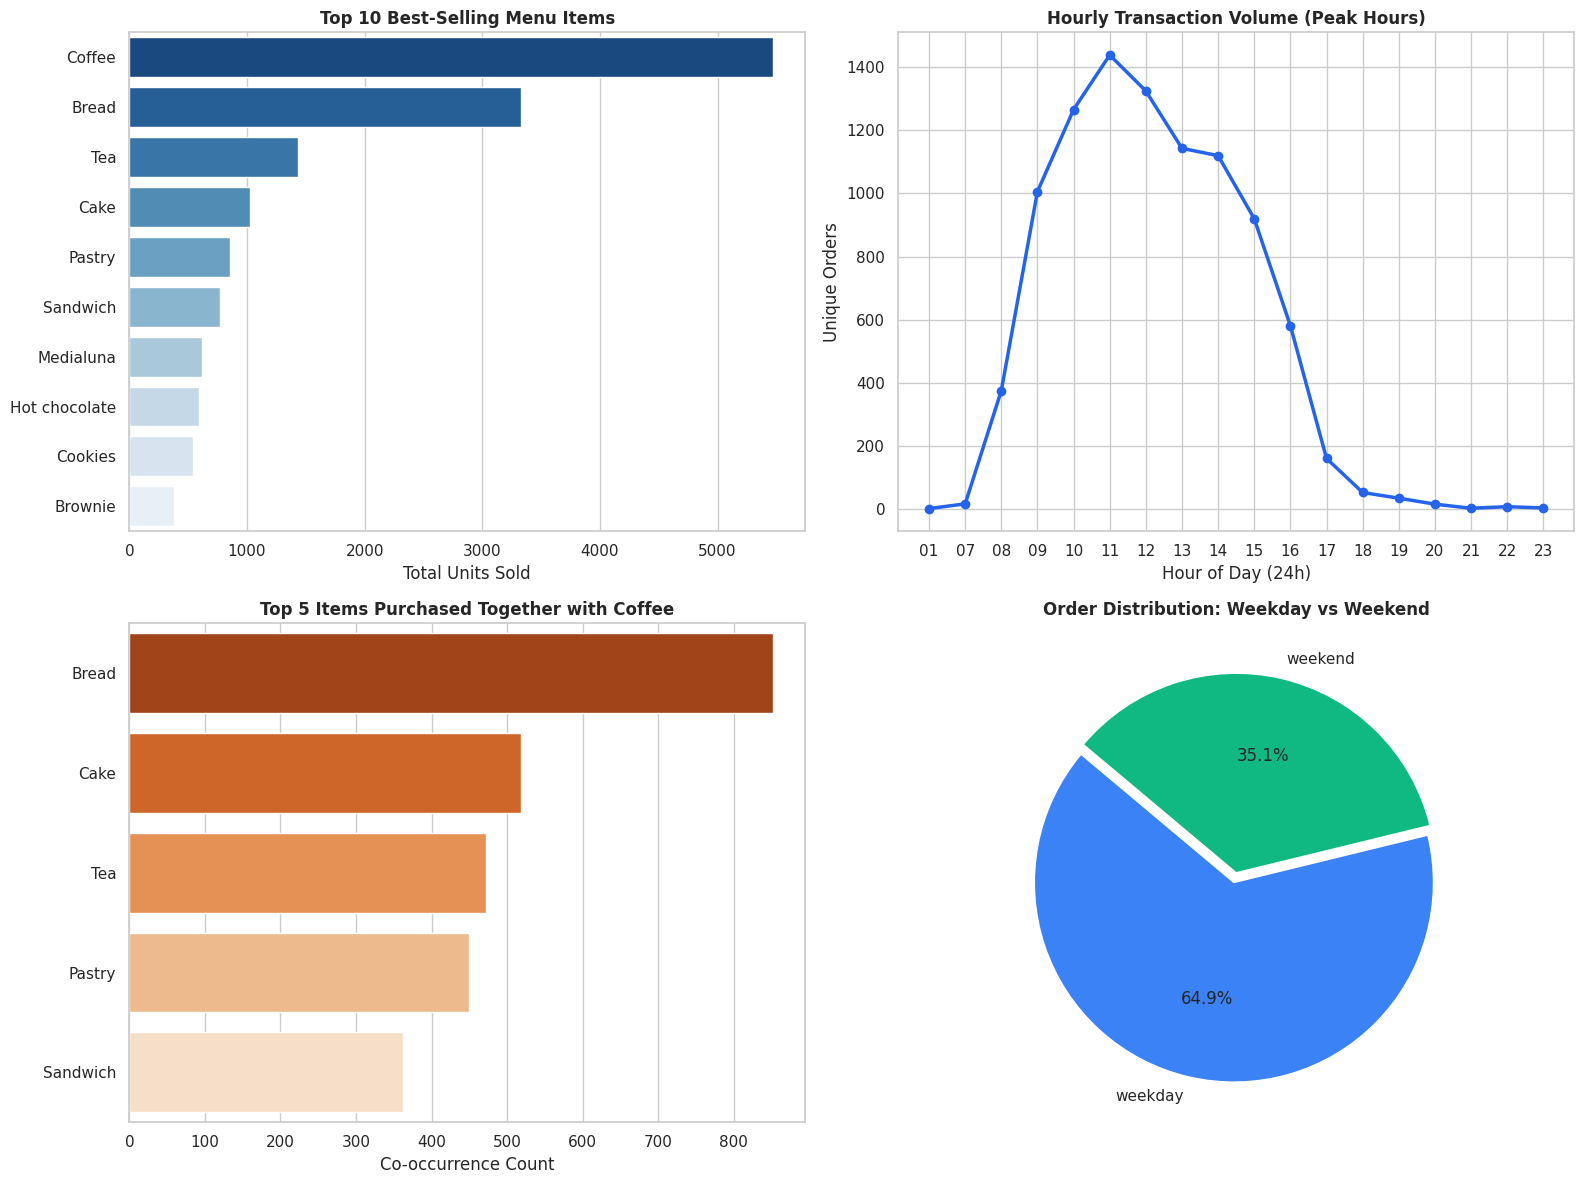

In [102]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.barplot(data=df_top10, x='total_units_sold', y='item_name', ax=axes[0, 0], palette='Blues_r')
axes[0, 0].set_title('Top 10 Best-Selling Menu Items', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Total Units Sold')
axes[0, 0].set_ylabel('')

df_hourly_sorted = df_hourly.sort_values('order_hour')
axes[0, 1].plot(df_hourly_sorted['order_hour'], df_hourly_sorted['unique_orders'], marker='o', color='#2563EB', linewidth=2.5)
axes[0, 1].set_title('Hourly Transaction Volume (Peak Hours)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Hour of Day (24h)')
axes[0, 1].set_ylabel('Unique Orders')

sns.barplot(data=df_pairing, x='transaction_co_occurrence', y='paired_item', ax=axes[1, 0], palette='Oranges_r')
axes[1, 0].set_title('Top 5 Items Purchased Together with Coffee', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Co-occurrence Count')
axes[1, 0].set_ylabel('')

q_daytype = """
SELECT weekday_weekend, COUNT(DISTINCT transaction_id) AS total_orders
FROM fact_pos_transactions
GROUP BY weekday_weekend;
"""
df_daytype = pd.read_sql(q_daytype, conn)

axes[1, 1].pie(df_daytype['total_orders'], labels=df_daytype['weekday_weekend'], autopct='%1.1f%%',
               colors=['#3B82F6', '#10B981'], startangle=140, explode=(0.05, 0))
axes[1, 1].set_title('Order Distribution: Weekday vs Weekend', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## Kesimpulan & Rekomendasi Bisnis
1. **Penerapan Paket Bundling Pagi:** Kopi menyumbang lebih dari 26% total penjualan dan paling sering dibeli bersama Bread serta Cake. Disarankan membuat paket kombo sarapan pagi untuk menaikkan ukuran keranjang belanja (*basket size*).
2. **Optimalisasi Shift Karyawan:** Puncak transaksi berada pada jam 10.00 hingga 14.00 dengan volume tertinggi pada jam 11.00. Alokasi staf kasir dan barista perlu dimaksimalkan pada rentang waktu ini.
3. **Rasionalisasi Menu:** Menu-menu dengan total penjualan di bawah 20 unit perlu ditinjau ulang untuk efisiensi rantai pasok dan pengurangan limbah bahan baku.